## Augmented Binary Encoding

Sensor count: $ 2 + 4 + 8 + ...$


010000
000001

                > 010001

                000011        010011

                > 010010

010000         010100         010110
000100         110000         110010        110110
001000         000110         110100
100000         100010         100110

                > 100100

                001100         101100

                > 101000

001000
100000


## Redundant Binary Encoding

Sensor count: $ 2 + 2 + 2 + ... $

> 0101

> 0110



> 1001

> 1010


## Non-redundant Binary Encoding

Sensor count: $1 + 1 + 1 + ...$

Reduction from RBE (4-bit) → NRBE (2-bit):

- Bit0 NRBE = Bit0 RBE
- Bit1 NRBE = Bit2 RBE

Valid reconstructions (from valid RBE):

> 00

> 01

> 10

> 11


Saved image successfully


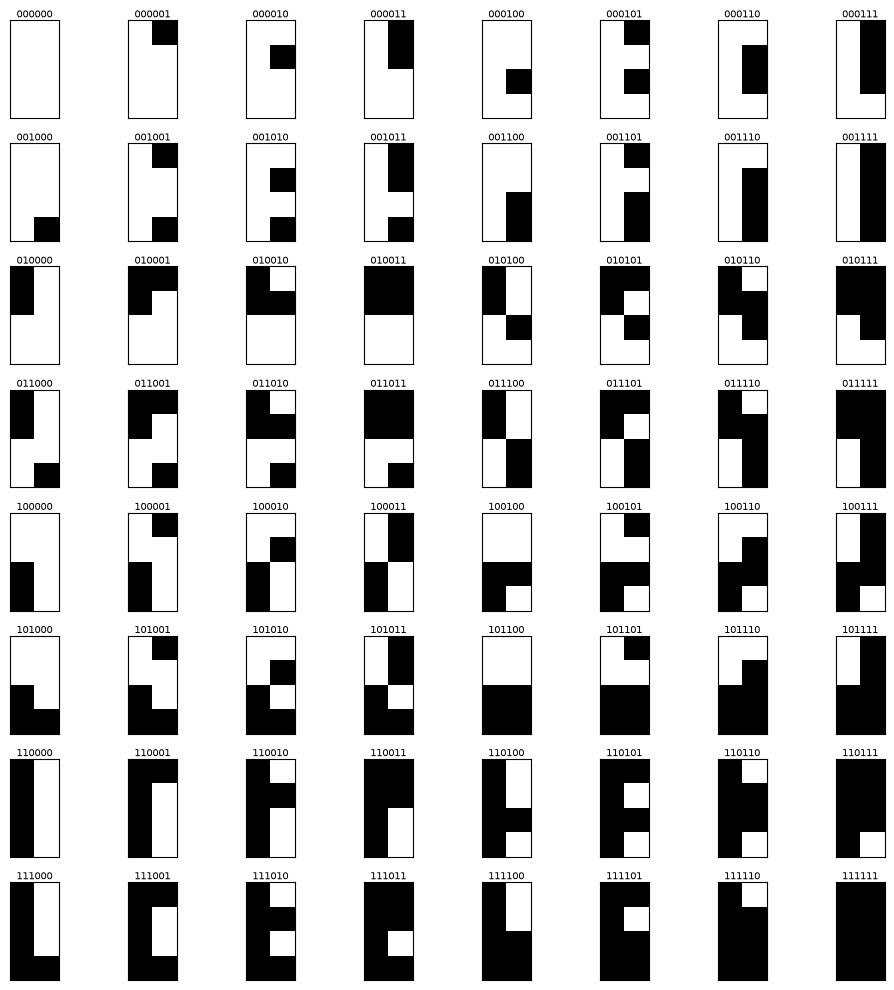

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure
fig, axes = plt.subplots(8, 8, figsize=(10, 10))

for val in range(64):
    row_idx = val // 8
    col_idx = val % 8
    ax = axes[row_idx, col_idx]
    
    # Create 4x2 array (4 rows, 2 columns) initialized to light (e.g. 1.0 for white)
    # Note: array shape is (rows, cols) = (4, 2)
    # y is row index (0..3), x is col index (0..1)
    grid = np.ones((4, 2))
    
    # Check bit masks
    if val & 0b010000:
        grid[0, 0] = 0.0 # dark
        grid[1, 0] = 0.0 # dark
    if val & 0b100000:
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
        
    if val & 0b000001:
        grid[0, 1] = 0.0
    if val & 0b000010:
        grid[1, 1] = 0.0
    if val & 0b000100:
        grid[2, 1] = 0.0
    if val & 0b001000:
        grid[3, 1] = 0.0

    ax.imshow(grid, cmap='gray', vmin=0, vmax=1, origin='upper')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{val:06b}", fontsize=7, pad=2)

plt.tight_layout()
# plt.savefig("binary_states.png", dpi=150)
print("Saved image successfully")

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Map 6-bit to 4-bit according to the user's instructions:
# 6-bit value: b5 b4 b3 b2 b1 b0
# b5 -> 4-bit bit 3 (0b1000)
# b4 -> 4-bit bit 2 (0b0100)
# b3 OR b1 -> 4-bit bit 1 (0b0010)
# b2 OR b0 -> 4-bit bit 0 (0b0001)

def six_to_four(v6):
    b0 = (v6 >> 0) & 1
    b1 = (v6 >> 1) & 1
    b2 = (v6 >> 2) & 1
    b3 = (v6 >> 3) & 1
    b4 = (v6 >> 4) & 1
    b5 = (v6 >> 5) & 1
    
    bit0 = b0 | b2
    bit1 = b1 | b3
    bit2 = b4
    bit3 = b5
    
    return (bit3 << 3) | (bit2 << 2) | (bit1 << 1) | bit0

mapping = {v4: [] for v4 in range(16)}
for v6 in range(64):
    v4 = six_to_four(v6)
    mapping[v4].append(v6)

for v4, v6_list in mapping.items():
    print(f"4-bit {v4:04b} ({v4:2d}): {len(v6_list)} items -> {[f'{v:06b}' for v in v6_list]}")

4-bit 0000 ( 0): 1 items -> ['000000']
4-bit 0001 ( 1): 3 items -> ['000001', '000100', '000101']
4-bit 0010 ( 2): 3 items -> ['000010', '001000', '001010']
4-bit 0011 ( 3): 9 items -> ['000011', '000110', '000111', '001001', '001011', '001100', '001101', '001110', '001111']
4-bit 0100 ( 4): 1 items -> ['010000']
4-bit 0101 ( 5): 3 items -> ['010001', '010100', '010101']
4-bit 0110 ( 6): 3 items -> ['010010', '011000', '011010']
4-bit 0111 ( 7): 9 items -> ['010011', '010110', '010111', '011001', '011011', '011100', '011101', '011110', '011111']
4-bit 1000 ( 8): 1 items -> ['100000']
4-bit 1001 ( 9): 3 items -> ['100001', '100100', '100101']
4-bit 1010 (10): 3 items -> ['100010', '101000', '101010']
4-bit 1011 (11): 9 items -> ['100011', '100110', '100111', '101001', '101011', '101100', '101101', '101110', '101111']
4-bit 1100 (12): 1 items -> ['110000']
4-bit 1101 (13): 3 items -> ['110001', '110100', '110101']
4-bit 1110 (14): 3 items -> ['110010', '111000', '111010']
4-bit 1111 (15)

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Map 4-bit (RBE) to 2-bit (NRBE):
# 4-bit value: b3 b2 b1 b0
# b0 -> 2-bit bit 0 (0b01)
# b2 -> 2-bit bit 1 (0b10)
# (b1 and b3 are dropped)

def four_to_two(v4):
    b0 = (v4 >> 0) & 1
    b2 = (v4 >> 2) & 1
    return (b2 << 1) | b0

mapping_4_to_2 = {v2: [] for v2 in range(4)}
for v4 in range(16):
    v2 = four_to_two(v4)
    mapping_4_to_2[v2].append(v4)

for v2, v4_list in mapping_4_to_2.items():
    print(f"2-bit {v2:02b} ({v2}): {len(v4_list)} items -> {[f'{v:04b}' for v in v4_list]}")


2-bit 00 (0): 4 items -> ['0000', '0010', '1000', '1010']
2-bit 01 (1): 4 items -> ['0001', '0011', '1001', '1011']
2-bit 10 (2): 4 items -> ['0100', '0110', '1100', '1110']
2-bit 11 (3): 4 items -> ['0101', '0111', '1101', '1111']


In [5]:
import numpy as np
from scipy.ndimage import label

def get_6bit_grid(v6):
    grid = np.ones((4, 2))
    if v6 & 0b010000:  # Bit 4
        grid[0, 0] = 0.0
        grid[1, 0] = 0.0
    if v6 & 0b100000:  # Bit 5
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
    if v6 & 0b000001:  # Bit 0
        grid[0, 1] = 0.0
    if v6 & 0b000010:  # Bit 1
        grid[1, 1] = 0.0
    if v6 & 0b000100:  # Bit 2
        grid[2, 1] = 0.0
    if v6 & 0b001000:  # Bit 3
        grid[3, 1] = 0.0
    return grid

# 4-connectivity structure for grid:
# [[0, 1, 0],
#  [1, 1, 1],
#  [0, 1, 0]]
structure_4 = np.array([[0, 1, 0],
                        [1, 1, 1],
                        [0, 1, 0]])

green_list = []
blue_list = []
none_list = []

for v6 in range(64):
    grid = get_6bit_grid(v6)
    binary_black = (grid == 0.0).astype(int)
    
    labeled_array, num_features = label(binary_black, structure=structure_4)
    
    if num_features == 1:
        green_list.append(v6)
    elif num_features > 1:
        blue_list.append(v6)
    else:
        none_list.append(v6)

print(f"Single contiguous region (Green, {len(green_list)}): {[f'{v:06b}' for v in green_list]}")
print(f"Disjointed regions (Blue, {len(blue_list)}): {[f'{v:06b}' for v in blue_list]}")
print(f"No regions (None, {len(none_list)}): {[f'{v:06b}' for v in none_list]}")

Single contiguous region (Green, 42): ['000001', '000010', '000011', '000100', '000110', '000111', '001000', '001100', '001110', '001111', '010000', '010001', '010010', '010011', '010110', '010111', '011110', '011111', '100000', '100100', '100110', '100111', '101000', '101100', '101110', '101111', '110000', '110001', '110010', '110011', '110100', '110101', '110110', '110111', '111000', '111001', '111010', '111011', '111100', '111101', '111110', '111111']
Disjointed regions (Blue, 21): ['000101', '001001', '001010', '001011', '001101', '010100', '010101', '011000', '011001', '011010', '011011', '011100', '011101', '100001', '100010', '100011', '100101', '101001', '101010', '101011', '101101']
No regions (None, 1): ['000000']


In [6]:
def count_contiguous_regions(grid):
    black_mask = (grid == 0.0)
    visited = np.zeros_like(black_mask, dtype=bool)
    components = 0
    
    rows, cols = black_mask.shape
    for r in range(rows):
        for c in range(cols):
            if black_mask[r, c] and not visited[r, c]:
                components += 1
                queue = [(r, c)]
                visited[r, c] = True
                while queue:
                    curr_r, curr_c = queue.pop(0)
                    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        nr, nc = curr_r + dr, curr_c + dc
                        if 0 <= nr < rows and 0 <= nc < cols:
                            if black_mask[nr, nc] and not visited[nr, nc]:
                                visited[nr, nc] = True
                                queue.append((nr, nc))
    return components

# Compare scipy label with custom BFS
scipy_green = []
scipy_blue = []
bfs_green = []
bfs_blue = []

for v6 in range(64):
    grid = get_6bit_grid(v6)
    
    # scipy
    black_pixels = (grid == 0.0).astype(int)
    _, num_c_scipy = label(black_pixels, structure=structure_4)
    if num_c_scipy == 1: scipy_green.append(v6)
    elif num_c_scipy > 1: scipy_blue.append(v6)
    
    # BFS
    num_c_bfs = count_contiguous_regions(grid)
    if num_c_bfs == 1: bfs_green.append(v6)
    elif num_c_bfs > 1: bfs_blue.append(v6)

assert scipy_green == bfs_green
assert scipy_blue == bfs_blue
print("BFS custom logic perfectly matches scipy.ndimage.label!")

BFS custom logic perfectly matches scipy.ndimage.label!


Saved 16-row colored mapping grid successfully.


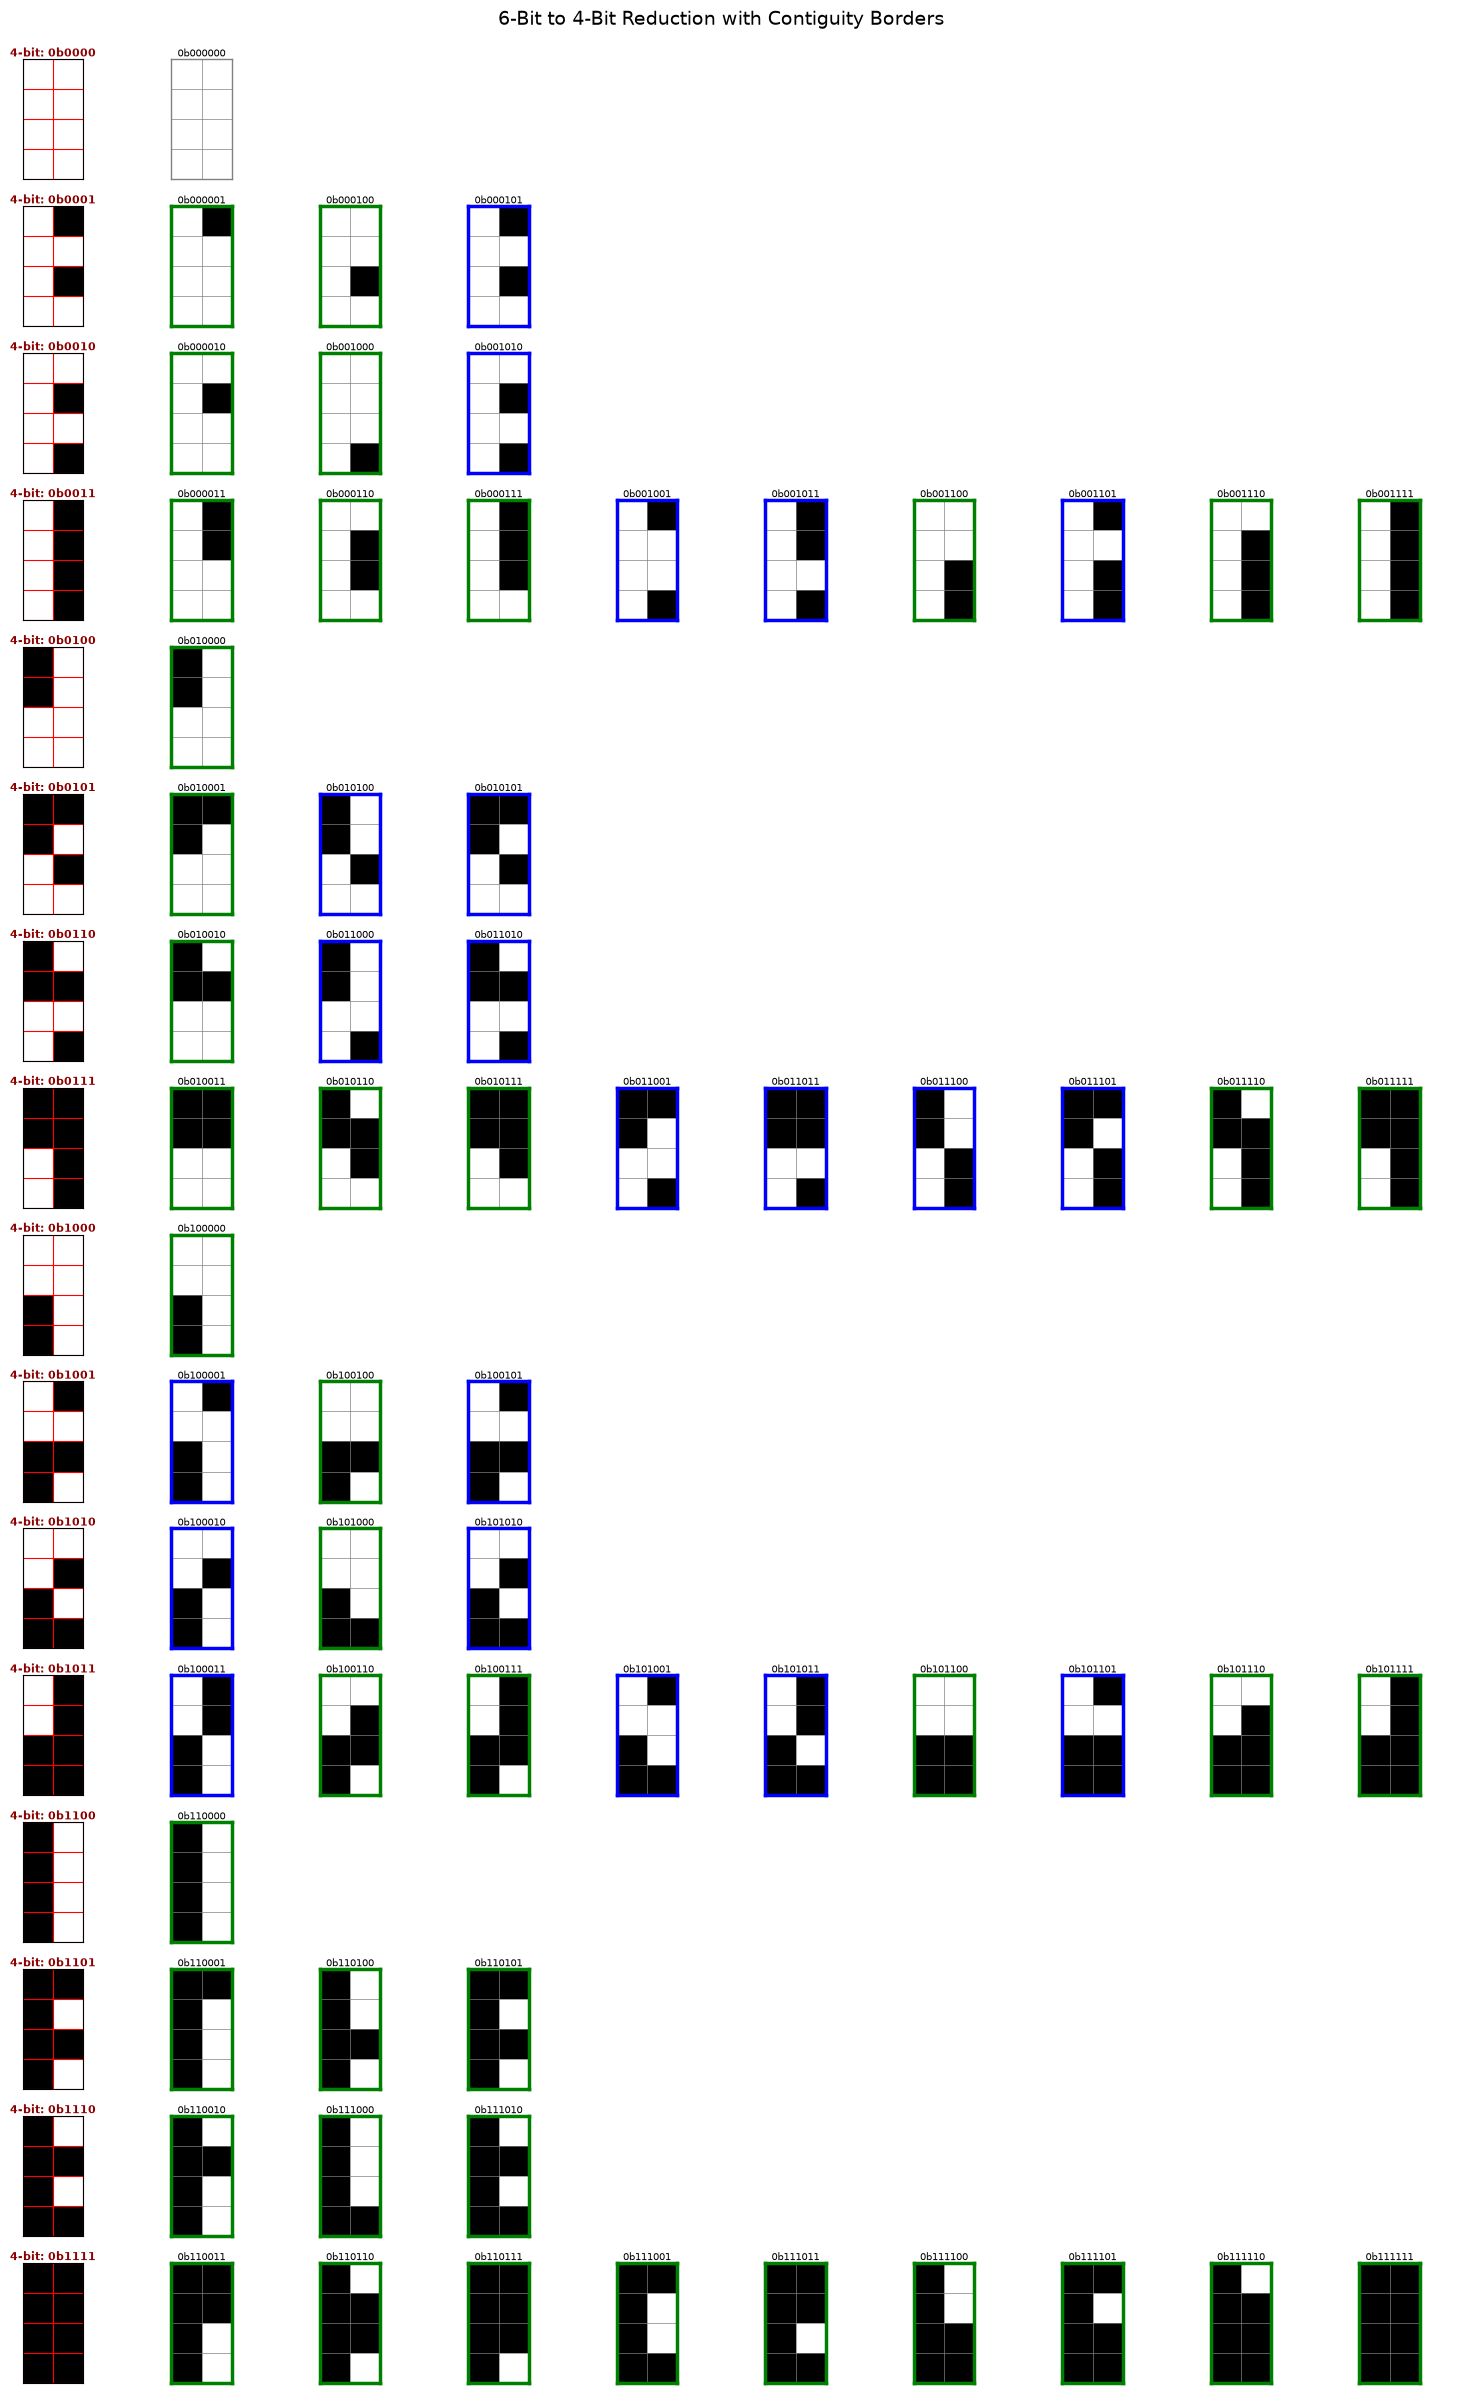

In [7]:
def get_4bit_grid(v4):
    grid = np.ones((4, 2))
    if v4 & 0b0100:
        grid[0, 0] = 0.0
        grid[1, 0] = 0.0
    if v4 & 0b1000:
        grid[2, 0] = 0.0
        grid[3, 0] = 0.0
    if v4 & 0b0001:
        grid[0, 1] = 0.0
        grid[2, 1] = 0.0
    if v4 & 0b0010:
        grid[1, 1] = 0.0
        grid[3, 1] = 0.0
    return grid

def reduce_6_to_4(v6):
    b0 = (v6 >> 0) & 1
    b1 = (v6 >> 1) & 1
    b2 = (v6 >> 2) & 1
    b3 = (v6 >> 3) & 1
    b4 = (v6 >> 4) & 1
    b5 = (v6 >> 5) & 1
    return (b5 << 3) | (b4 << 2) | ((b1 | b3) << 1) | (b0 | b2)


def get_2bit_grid(v2):
    """NRBE physical layout: Bit0 = RBE Bit0, Bit1 = RBE Bit2.

    When a bit is 1: its RBE footprint is black.
    When a bit is 0: grey on the complementary cells of that footprint
    (right-column Bit1 cells for NRBE Bit0; left-column Bit3 cells for NRBE Bit1).
    """
    grid = np.ones((4, 2))
    # Bit0 NRBE = Bit0 RBE: black [0,1]&[2,1]; inactive -> grey complement [1,1]&[3,1]
    if v2 & 0b01:
        grid[0, 1] = 0.0
        grid[2, 1] = 0.0
    else:
        grid[1, 1] = 0.5
        grid[3, 1] = 0.5
    # Bit1 NRBE = Bit2 RBE: black [0,0]&[1,0]; inactive -> grey complement [2,0]&[3,0]
    if v2 & 0b10:
        grid[0, 0] = 0.0
        grid[1, 0] = 0.0
    else:
        grid[2, 0] = 0.5
        grid[3, 0] = 0.5
    return grid

def reduce_4_to_2(v4):
    """RBE (4-bit) -> NRBE (2-bit): bit0=b0, bit1=b2."""
    b0 = (v4 >> 0) & 1
    b2 = (v4 >> 2) & 1
    return (b2 << 1) | b0

mapping = {v4: [] for v4 in range(16)}
for v6 in range(64):
    v4 = reduce_6_to_4(v6)
    mapping[v4].append(v6)

max_cols = 10
fig, axes = plt.subplots(16, max_cols, figsize=(15, 24))

for row in range(16):
    v4 = row
    v6_matches = mapping[v4]
    
    # Col 0: 4-bit target
    ax = axes[row, 0]
    grid_4 = get_4bit_grid(v4)
    ax.imshow(grid_4, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
    ax.set_xticks(np.arange(0, 3, 1))
    ax.set_yticks(np.arange(0, 5, 1))
    ax.grid(color='red', linestyle='-', linewidth=0.8)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(length=0)
    ax.set_title(f"4-bit: 0b{v4:04b}", fontsize=8, color='darkred', weight='bold', pad=2)
    
    # Cols 1..9: 6-bit states with colored borders
    for col in range(1, max_cols):
        ax_sub = axes[row, col]
        v6_idx = col - 1
        if v6_idx < len(v6_matches):
            v6 = v6_matches[v6_idx]
            grid_6 = get_6bit_grid(v6)
            ax_sub.imshow(grid_6, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
            ax_sub.set_xticks(np.arange(0, 3, 1))
            ax_sub.set_yticks(np.arange(0, 5, 1))
            ax_sub.grid(color='gray', linestyle='-', linewidth=0.5)
            ax_sub.set_xticklabels([])
            ax_sub.set_yticklabels([])
            ax_sub.tick_params(length=0)
            ax_sub.set_title(f"0b{v6:06b}", fontsize=7, pad=2)
            
            # Apply colored border based on connectivity
            num_components = count_contiguous_regions(grid_6)
            if num_components == 1:
                border_color = 'green'
                lw = 2.5
            elif num_components > 1:
                border_color = 'blue'
                lw = 2.5
            else:
                border_color = 'gray'
                lw = 1.0
                
            for spine in ax_sub.spines.values():
                spine.set_color(border_color)
                spine.set_linewidth(lw)
        else:
            ax_sub.axis('off')

plt.suptitle("6-Bit to 4-Bit Reduction with Contiguity Borders", fontsize=14, y=0.995)
plt.tight_layout()
# plt.savefig("16row_colored_mapping.png", dpi=150, bbox_inches='tight')
print("Saved 16-row colored mapping grid successfully.")


## Ambiguity Types for Augmented Binary Encoding

- Contiguous trigger ambiguity: single-bit, dual-bit (single layer), triple bit.
    - Two trigger sections that are not connected (not considering diagonals)
- Disjointed trigger ambiguity: dual-bit, triple bit, quad bit.


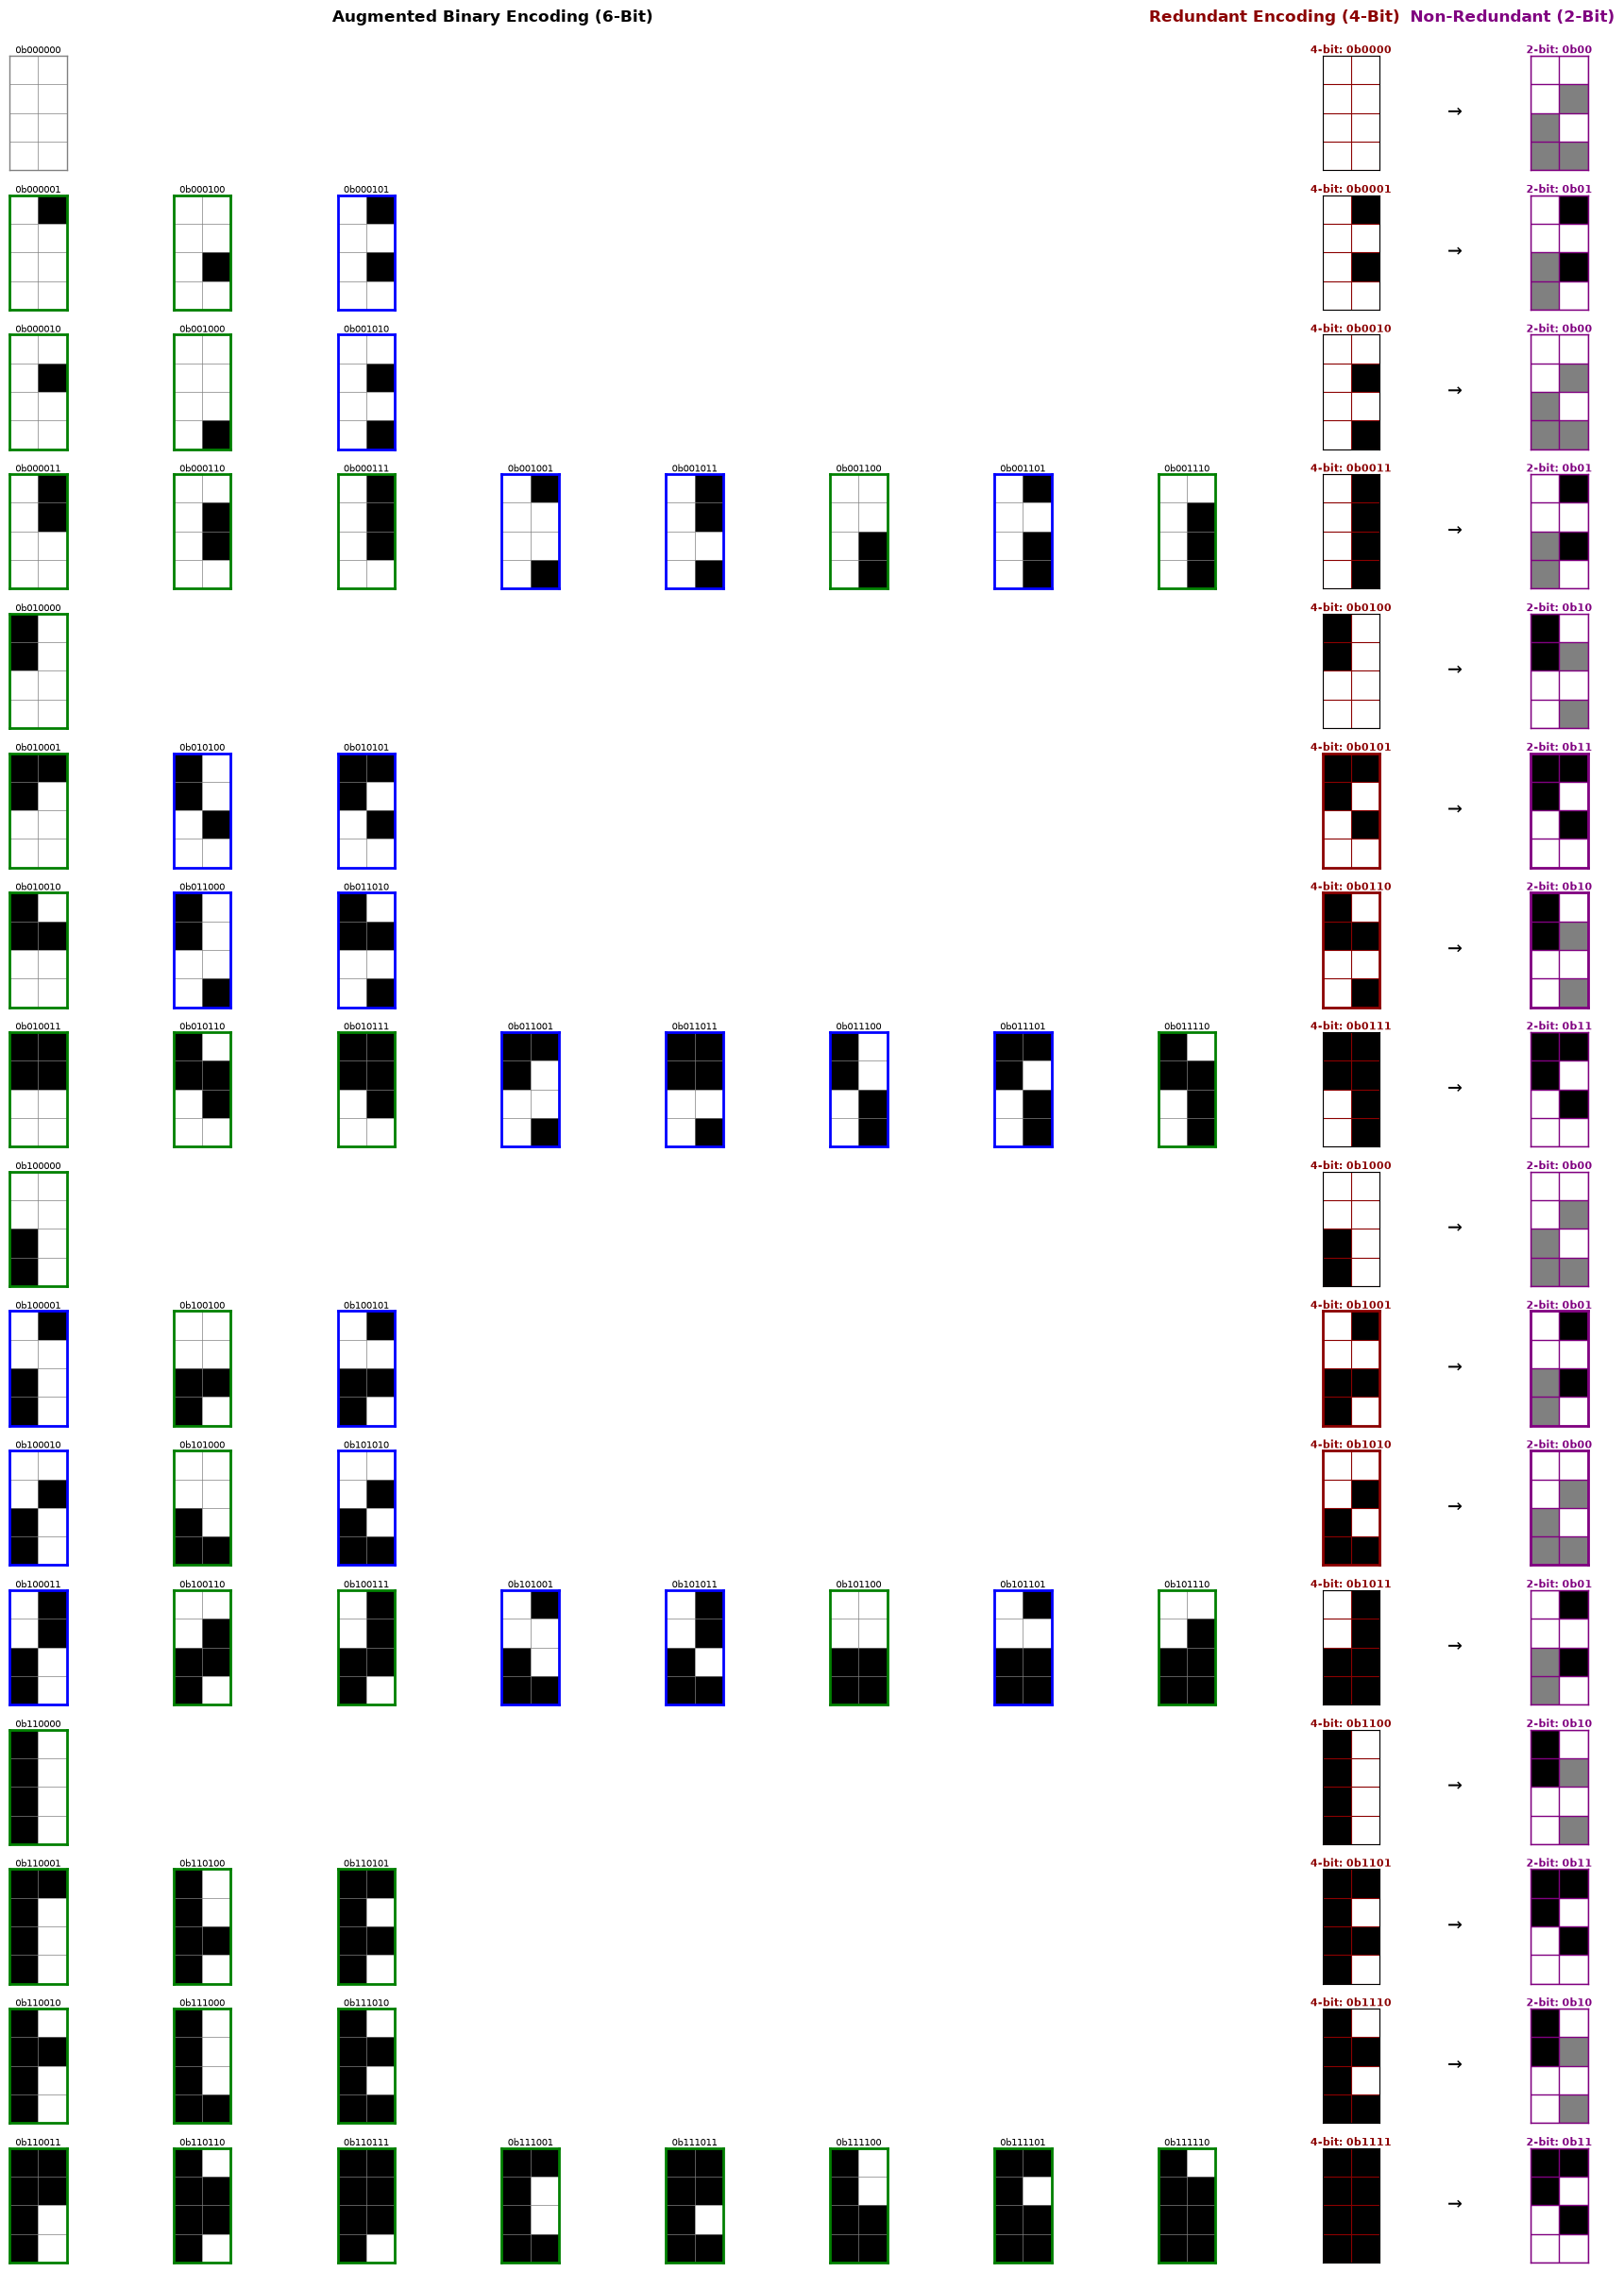

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure 6-bit -> 4-bit mapping exists (ABE -> RBE)
mapping_6_to_4 = {v4: [] for v4 in range(16)}
for v6 in range(64):
    mapping_6_to_4[reduce_6_to_4(v6)].append(v6)

# Valid RBE states (redundant binary encoding)
VALID_RBE = {0b0101, 0b0110, 0b1001, 0b1010}

# Construct total layout: 16 rows x 11 columns
# [ABE x8 | RBE | arrow | NRBE]
fig, axes = plt.subplots(
    16, 11, figsize=(18, 24),
    gridspec_kw={'width_ratios': [1] * 8 + [1, 0.2, 1]},
)

for row in range(16):
    v4 = row
    v6_matches = mapping_6_to_4[v4]
    v2 = reduce_4_to_2(v4)

    # --------------------------------------------------------------------------
    # SECTION 1: 6-Bit Augmented Binary Encoding (Cols 0..7)
    # --------------------------------------------------------------------------
    for col in range(8):
        ax_sub = axes[row, col]
        if col < len(v6_matches):
            v6 = v6_matches[col]
            grid_6 = get_6bit_grid(v6)
            ax_sub.imshow(grid_6, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
            ax_sub.set_xticks(np.arange(0, 3, 1))
            ax_sub.set_yticks(np.arange(0, 5, 1))
            ax_sub.grid(color='gray', linestyle='-', linewidth=0.5)
            ax_sub.set_xticklabels([])
            ax_sub.set_yticklabels([])
            ax_sub.tick_params(length=0)
            ax_sub.set_title(f"0b{v6:06b}", fontsize=7, pad=2)

            num_components = count_contiguous_regions(grid_6)
            if num_components == 1:
                border_color, lw = 'green', 2.0
            elif num_components > 1:
                border_color, lw = 'blue', 2.0
            else:
                border_color, lw = 'gray', 1.0

            for spine in ax_sub.spines.values():
                spine.set_color(border_color)
                spine.set_linewidth(lw)
        else:
            ax_sub.axis('off')

    # --------------------------------------------------------------------------
    # SECTION 2: 4-Bit Redundant Binary Encoding (Col 8)
    # --------------------------------------------------------------------------
    ax_4bit = axes[row, 8]
    grid_4 = get_4bit_grid(v4)
    ax_4bit.imshow(grid_4, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
    ax_4bit.set_xticks(np.arange(0, 3, 1))
    ax_4bit.set_yticks(np.arange(0, 5, 1))
    ax_4bit.grid(color='darkred', linestyle='-', linewidth=0.8)
    ax_4bit.set_xticklabels([])
    ax_4bit.set_yticklabels([])
    ax_4bit.tick_params(length=0)
    ax_4bit.set_title(f"4-bit: 0b{v4:04b}", fontsize=8, color='darkred', weight='bold', pad=2)
    if v4 in VALID_RBE:
        for spine in ax_4bit.spines.values():
            spine.set_color('darkred')
            spine.set_linewidth(2.0)

    # --------------------------------------------------------------------------
    # SECTION 3: 2-Bit Non-Redundant Binary Encoding (Col 10) & Arrow (Col 9)
    # RBE -> NRBE: Bit0_NRBE = Bit0_RBE, Bit1_NRBE = Bit2_RBE
    # Render NRBE for every RBE row (all 16), not only valid RBE.
    # --------------------------------------------------------------------------
    ax_sep = axes[row, 9]
    ax_2bit = axes[row, 10]

    ax_sep.axis('off')
    ax_sep.text(0.5, 0.5, r"$\rightarrow$", fontsize=14, ha='center', va='center')

    grid_2 = get_2bit_grid(v2)
    ax_2bit.imshow(grid_2, cmap='gray', vmin=0, vmax=1, origin='upper', extent=[0, 2, 4, 0])
    ax_2bit.set_xticks(np.arange(0, 3, 1))
    ax_2bit.set_yticks(np.arange(0, 5, 1))
    ax_2bit.grid(color='purple', linestyle='-', linewidth=1.0)
    ax_2bit.set_xticklabels([])
    ax_2bit.set_yticklabels([])
    ax_2bit.tick_params(length=0)
    ax_2bit.set_title(f"2-bit: 0b{v2:02b}", fontsize=8, color='purple', weight='bold', pad=2)

    # Emphasize NRBE that come from a valid RBE reconstruction
    if v4 in VALID_RBE:
        border_color, lw = 'purple', 2.0
    else:
        border_color, lw = 'purple', 1.0
    for spine in ax_2bit.spines.values():
        spine.set_color(border_color)
        spine.set_linewidth(lw)

# Section Headings
fig.text(0.32, 0.995, "Augmented Binary Encoding (6-Bit)", fontsize=12, weight='bold', ha='center')
fig.text(0.78, 0.995, "Redundant Encoding (4-Bit)", fontsize=12, color='darkred', weight='bold', ha='center')
fig.text(0.92, 0.995, "Non-Redundant (2-Bit)", fontsize=12, color='purple', weight='bold', ha='center')

plt.tight_layout()
plt.subplots_adjust(top=0.98)
# plt.savefig("pipeline_2bit_column_coloring.png", dpi=150, bbox_inches='tight')
plt.show()


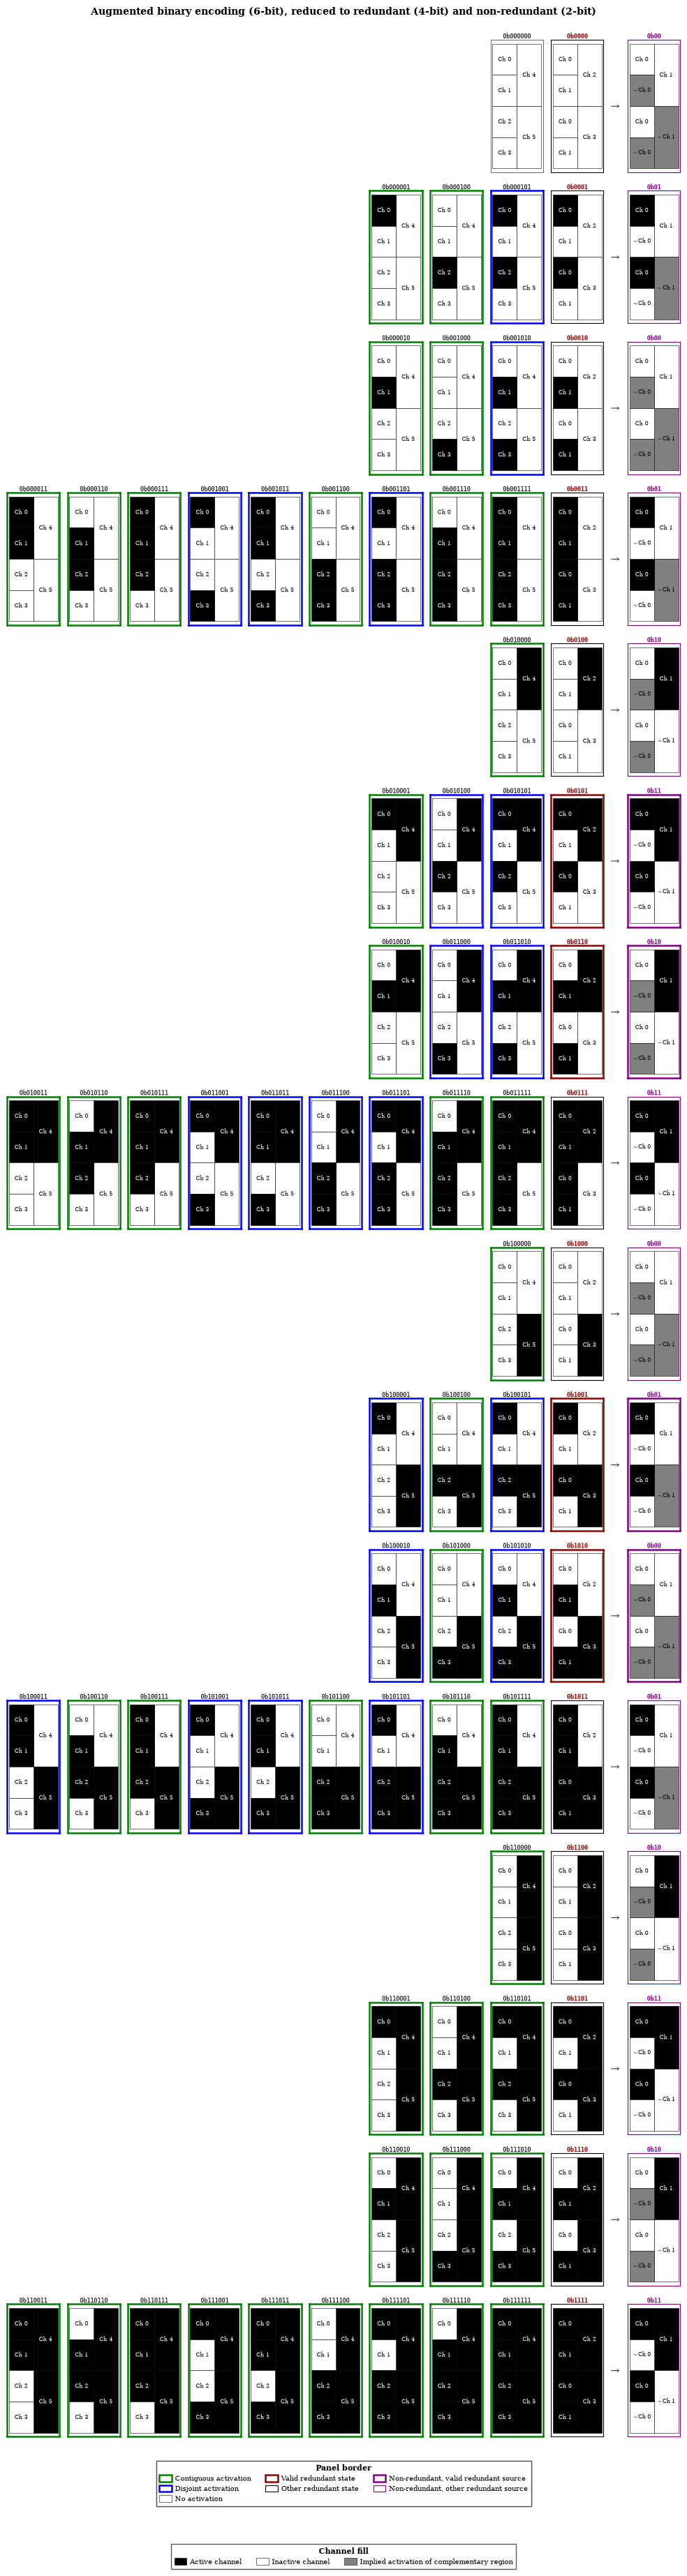

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch, Rectangle

# Ensure 6-bit -> 4-bit mapping exists (ABE -> RBE)
mapping_6_to_4 = {v4: [] for v4 in range(16)}
for v6 in range(64):
    mapping_6_to_4[reduce_6_to_4(v6)].append(v6)

# Valid RBE states (redundant binary encoding)
VALID_RBE = {0b0101, 0b0110, 0b1001, 0b1010}

_saved_rc = {k: plt.rcParams[k] for k in ("font.family", "mathtext.fontset")}
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
})

EDGE_LW = 0.4
ACTIVE = "black"
INACTIVE = "white"
COMPLEMENT = "0.5"

# Physical detector, corner-to-corner (same geometry as frequency_graphs schematics).
# Large channels sit on the right; the four short channels stack on the left.
ABE_RECTS = [
    ((12.5, +32), (25.0, 0), 4, "Ch 4"),
    ((12.5, -32), (25.0, 0), 5, "Ch 5"),
    ((0, +32), (12.5, +16), 0, "Ch 0"),
    ((0, +16), (12.5, 0), 1, "Ch 1"),
    ((0, -16), (12.5, 0), 2, "Ch 2"),
    ((0, -32), (12.5, -16), 3, "Ch 3"),
]

# RBE: Ch 2/3 are the former Ch 4/5 bars; Ch 0/1 each occupy two strips.
RBE_RECTS = [
    ((12.5, +32), (25.0, 0), 2, "Ch 2"),
    ((12.5, -32), (25.0, 0), 3, "Ch 3"),
    ((0, +32), (12.5, +16), 0, "Ch 0"),
    ((0, -16), (12.5, 0), 0, "Ch 0"),
    ((0, +16), (12.5, 0), 1, "Ch 1"),
    ((0, -32), (12.5, -16), 1, "Ch 1"),
]

# NRBE: Ch 0 = RBE bit0, Ch 1 = RBE bit2; complements are the other footprint.
NRBE_RECTS = [
    ((12.5, +32), (25.0, 0), 1, False, r"Ch 1"),
    ((12.5, -32), (25.0, 0), 1, True, r"$\sim$Ch 1"),
    ((0, +32), (12.5, +16), 0, False, r"Ch 0"),
    ((0, -16), (12.5, 0), 0, False, r"Ch 0"),
    ((0, +16), (12.5, 0), 0, True, r"$\sim$Ch 0"),
    ((0, -32), (12.5, -16), 0, True, r"$\sim$Ch 0"),
]

# Data window. A small margin keeps strokes inside the frame.
X0, X1 = -1.0, 26.0
Y0, Y1 = -34.0, 34.0
DATA_ASPECT = (Y1 - Y0) / (X1 - X0)


def _text_color(facecolor):
    return "white" if facecolor == ACTIVE else "black"


def _add_schematic_rect(ax, x0, y0, x1, y1, facecolor, label):
    x, y = min(x0, x1), min(y0, y1)
    w, h = abs(x1 - x0), abs(y1 - y0)
    ax.add_patch(Rectangle(
        (x, y), w, h,
        facecolor=facecolor, edgecolor="black", linewidth=EDGE_LW,
        joinstyle="miter",
    ))
    ax.text(
        (x0 + x1) / 2, (y0 + y1) / 2, label,
        ha="center", va="center", fontsize=5.5, color=_text_color(facecolor),
        clip_on=True,
    )


def _finish_schematic(ax, title, title_color, border_color, border_lw, title_weight="normal"):
    ax.set_xlim(X0, X1)
    ax.set_ylim(Y0, Y1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False, length=0)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(border_color)
        spine.set_linewidth(border_lw)
    ax.set_title(
        title, fontsize=6.5, color=title_color, weight=title_weight,
        pad=1.5, fontfamily="monospace",
    )


def draw_abe_schematic(ax, v6, border_color, border_lw):
    for (x0, y0), (x1, y1), bit, label in ABE_RECTS:
        facecolor = ACTIVE if (v6 & (1 << bit)) else INACTIVE
        _add_schematic_rect(ax, x0, y0, x1, y1, facecolor, label)
    _finish_schematic(ax, f"0b{v6:06b}", "black", border_color, border_lw)


def draw_rbe_schematic(ax, v4):
    for (x0, y0), (x1, y1), bit, label in RBE_RECTS:
        facecolor = ACTIVE if (v4 & (1 << bit)) else INACTIVE
        _add_schematic_rect(ax, x0, y0, x1, y1, facecolor, label)
    if v4 in VALID_RBE:
        border_color, border_lw = "darkred", 1.8
    else:
        border_color, border_lw = "black", 0.8
    _finish_schematic(
        ax, f"0b{v4:04b}", "darkred", border_color, border_lw, title_weight="bold",
    )


def draw_nrbe_schematic(ax, v2, from_valid_rbe):
    for (x0, y0), (x1, y1), bit, is_complement, label in NRBE_RECTS:
        bit_on = bool(v2 & (1 << bit))
        if bit_on and not is_complement:
            facecolor = ACTIVE
        elif (not bit_on) and is_complement:
            facecolor = COMPLEMENT
        else:
            facecolor = INACTIVE
        _add_schematic_rect(ax, x0, y0, x1, y1, facecolor, label)
    border_lw = 1.8 if from_valid_rbe else 0.8
    _finish_schematic(
        ax, f"0b{v2:02b}", "purple", "purple", border_lw, title_weight="bold",
    )


# Every 4-bit code has at most 9 augmented parents. Panels are right-aligned
# so each code sits against its redundant and non-redundant reductions.
N_ABE = max(len(v) for v in mapping_6_to_4.values())
N_COLS = N_ABE + 3  # ABE | RBE | arrow | NRBE
ARROW_COL = N_ABE + 1
RBE_COL = N_ABE
NRBE_COL = N_ABE + 2

fig = plt.figure(figsize=(10.0, 28.0))
gs = fig.add_gridspec(
    16, N_COLS,
    width_ratios=[1.0] * N_ABE + [1.0, 0.16, 1.0],
    wspace=0.16,
    hspace=0.14,
    left=0.008,
    right=0.992,
    top=0.968,
    bottom=0.055,
)
axes = np.empty((16, N_COLS), dtype=object)
for r in range(16):
    for c in range(N_COLS):
        axes[r, c] = fig.add_subplot(gs[r, c])

for row in range(16):
    v4 = row
    v6_matches = mapping_6_to_4[v4]
    v2 = reduce_4_to_2(v4)
    n_match = len(v6_matches)

    for col in range(N_ABE):
        ax_sub = axes[row, col]
        src_i = col - (N_ABE - n_match)
        if src_i < 0:
            ax_sub.axis("off")
            continue
        v6 = v6_matches[src_i]
        num_components = count_contiguous_regions(get_6bit_grid(v6))
        if num_components == 1:
            border_color, lw = "green", 1.8
        elif num_components > 1:
            border_color, lw = "blue", 1.8
        else:
            border_color, lw = "0.45", 0.8
        draw_abe_schematic(ax_sub, v6, border_color, lw)

    draw_rbe_schematic(axes[row, RBE_COL], v4)

    ax_sep = axes[row, ARROW_COL]
    ax_sep.axis("off")
    ax_sep.text(0.5, 0.5, r"$\rightarrow$", fontsize=11, ha="center", va="center", color="0.15")

    draw_nrbe_schematic(axes[row, NRBE_COL], v2, from_valid_rbe=(v4 in VALID_RBE))

# Match the axes box to the detector window so frames fill their cells,
# at a width that keeps channel labels and the legend readable.
fig.canvas.draw()
pos = axes[0, 0].get_position()
target_width = 9.8
fig_h = target_width * DATA_ASPECT * pos.width / pos.height
fig.set_size_inches(target_width, fig_h, forward=True)
fig.canvas.draw()

title_top = axes[0, N_ABE - 1].title.get_window_extent(fig.canvas.get_renderer()).transformed(
    fig.transFigure.inverted()
).y1
fig.text(
    0.5, min(0.992, title_top + 0.006),
    "Augmented binary encoding (6-bit), reduced to redundant (4-bit) and non-redundant (2-bit)",
    fontsize=10, weight="bold", ha="center", va="bottom",
)

border_handles = [
    Patch(facecolor="white", edgecolor="green", linewidth=1.8, label="Contiguous activation"),
    Patch(facecolor="white", edgecolor="blue", linewidth=1.8, label="Disjoint activation"),
    Patch(facecolor="white", edgecolor="0.45", linewidth=0.8, label="No activation"),
    Patch(facecolor="white", edgecolor="darkred", linewidth=1.8, label="Valid redundant state"),
    Patch(facecolor="white", edgecolor="black", linewidth=0.8, label="Other redundant state"),
    Patch(facecolor="white", edgecolor="purple", linewidth=1.8, label="Non-redundant, valid redundant source"),
    Patch(facecolor="white", edgecolor="purple", linewidth=0.8, label="Non-redundant, other redundant source"),
]
fill_handles = [
    Patch(facecolor="black", edgecolor="black", linewidth=0.4, label="Active channel"),
    Patch(facecolor="white", edgecolor="black", linewidth=0.4, label="Inactive channel"),
    Patch(facecolor=COMPLEMENT, edgecolor="black", linewidth=0.4,
          label="Implied activation of complementary region"),
]

legend_kw = dict(
    frameon=True,
    fancybox=False,
    edgecolor="0.35",
    framealpha=1.0,
    fontsize=7.5,
    borderpad=0.45,
    handlelength=1.7,
    handleheight=1.05,
    handletextpad=0.45,
    labelspacing=0.35,
    borderaxespad=0.2,
)
leg_border = fig.legend(
    handles=border_handles,
    loc="lower center",
    bbox_to_anchor=(0.50, 0.028),
    ncol=3,
    title="Panel border",
    **legend_kw,
)
leg_border.get_title().set_fontweight("bold")
leg_border.get_title().set_fontsize(8)
fig.add_artist(leg_border)
leg_fill = fig.legend(
    handles=fill_handles,
    loc="lower center",
    bbox_to_anchor=(0.50, 0.004),
    ncol=3,
    title="Channel fill",
    **legend_kw,
)
leg_fill.get_title().set_fontweight("bold")
leg_fill.get_title().set_fontsize(8)



plt.savefig("state_reduction.svg", dpi=300)
plt.show()
plt.rcParams.update(_saved_rc)
